# Import Necessary Model

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Read Data And Perform Exploratory Data Analysis

In [2]:
data=pd.read_csv('/kaggle/input/bitcoin-historical-market-data-2013present/btc-usd-max.csv')

In [3]:
data.head(10)

,snapped_at,price,market_cap,total_volume
0,2013-04-28 00:00:00 UTC,135.30,1.500518e+09,0.0
1,2013-04-29 00:00:00 UTC,141.96,1.575032e+09,0.0
2,2013-04-30 00:00:00 UTC,135.30,1.501657e+09,0.0
3,2013-05-01 00:00:00 UTC,117.00,1.298952e+09,0.0
4,2013-05-02 00:00:00 UTC,103.43,1.148668e+09,0.0
5,2013-05-03 00:00:00 UTC,91.01,1.011066e+09,0.0
6,2013-05-04 00:00:00 UTC,111.25,1.236352e+09,0.0
7,2013-05-05 00:00:00 UTC,116.79,1.298378e+09,0.0
8,2013-05-06 00:00:00 UTC,118.33,1.315992e+09,0.0
9,2013-05-07 00:00:00 UTC,106.40,1.183766e+09,0.0


In [4]:
data.tail(10)

,snapped_at,price,market_cap,total_volume
4654,2026-01-26 00:00:00 UTC,86548.322135,1.731460e+12,3.991252e+10
4655,2026-01-27 00:00:00 UTC,88307.861207,1.764540e+12,5.064443e+10
4656,2026-01-28 00:00:00 UTC,89204.222396,1.782509e+12,4.377846e+10
4657,2026-01-29 00:00:00 UTC,89162.097016,1.781310e+12,4.589325e+10
4658,2026-01-30 00:00:00 UTC,84570.409061,1.689640e+12,7.096260e+10
4659,2026-01-31 00:00:00 UTC,84141.778570,1.680808e+12,7.951546e+10
4660,2026-02-01 00:00:00 UTC,78725.858539,1.573735e+12,7.848854e+10
4661,2026-02-02 00:00:00 UTC,76937.064066,1.537520e+12,5.833074e+10
4662,2026-02-03 00:00:00 UTC,78767.658153,1.573217e+12,8.467513e+10
4663,2026-02-04 00:00:00 UTC,75638.956702,1.512166e+12,7.373422e+10


In [5]:
data.shape

(4664, 4)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4664 entries, 0 to 4663
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   snapped_at    4664 non-null   object 
 1   price         4664 non-null   float64
 2   market_cap    4664 non-null   float64
 3   total_volume  4664 non-null   float64
dtypes: float64(3), object(1)
memory usage: 145.9+ KB


In [7]:
data.describe()

,price,market_cap,total_volume
count,4664.000000,4.664000e+03,4.664000e+03
mean,24444.851442,4.724269e+11,1.874702e+10
std,31377.438053,6.223311e+11,2.204118e+10
min,67.809000,7.713681e+08,0.000000e+00
25%,660.621693,1.000328e+10,5.594911e+08
50%,9142.295158,1.630168e+11,1.266339e+10
75%,38542.124690,7.331868e+11,3.003588e+10
max,124773.508231,2.486073e+12,1.904603e+11


In [8]:
data.isnull().sum()

snapped_at      0
price           0
market_cap      0
total_volume    0
dtype: int64

In [9]:
data['snapped_at'] = pd.to_datetime(data['snapped_at'])

# Data Visualization 

<Axes: >

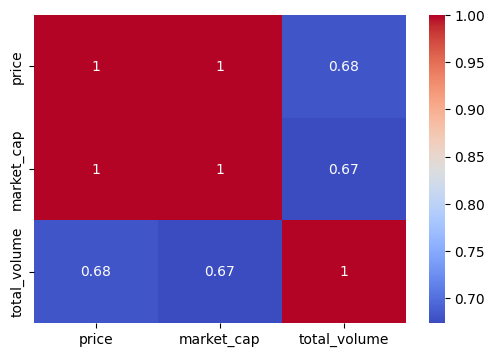

In [10]:
plt.figure(figsize=(6,4))
sns.heatmap(data[['price','market_cap','total_volume']].corr(),
            annot=True, cmap='coolwarm')


array([[<Axes: title={'center': 'price'}>,
        <Axes: title={'center': 'market_cap'}>],
       [<Axes: title={'center': 'total_volume'}>, <Axes: >]], dtype=object)

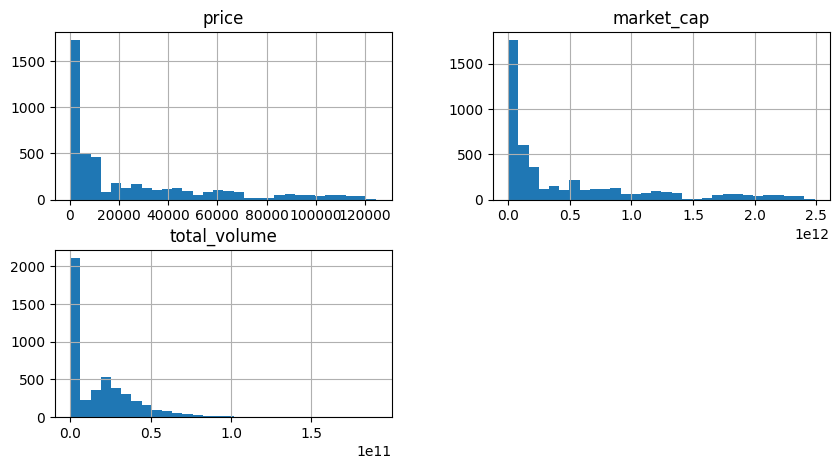

In [11]:
data[['price','market_cap','total_volume']].hist(
    figsize=(10,5), bins=30)


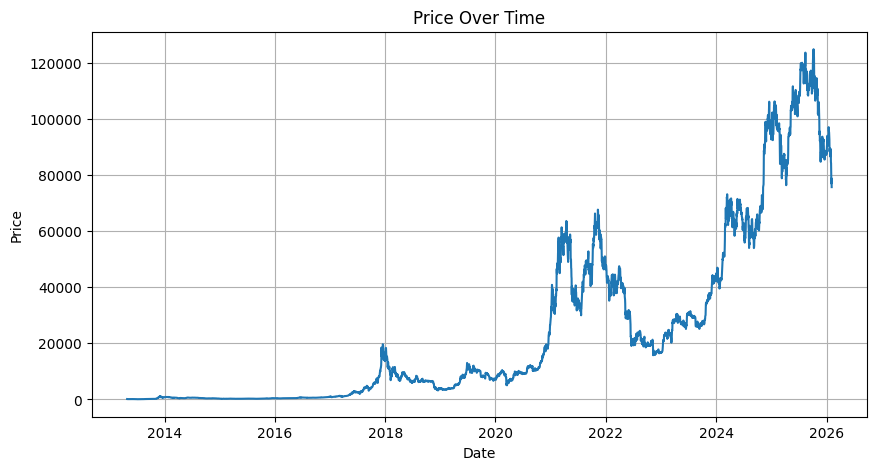

In [12]:
plt.figure(figsize=(10,5))
plt.plot(data['snapped_at'], data['price'])
plt.title("Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)



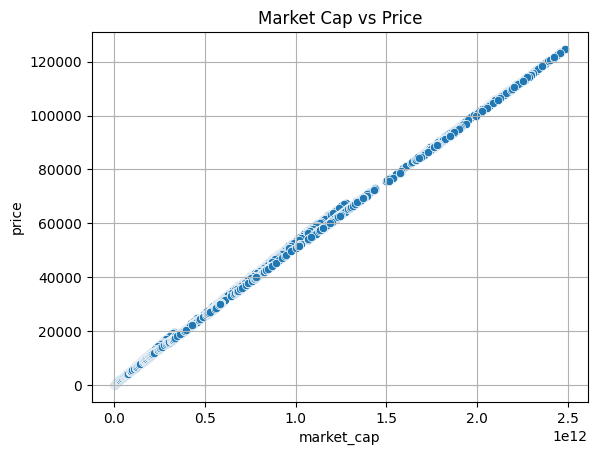

In [13]:
sns.scatterplot(x='market_cap', y='price', data=data)
plt.title("Market Cap vs Price")
plt.grid(True)
plt.show()


Text(0.5, 1.0, 'total_volume vs Price')

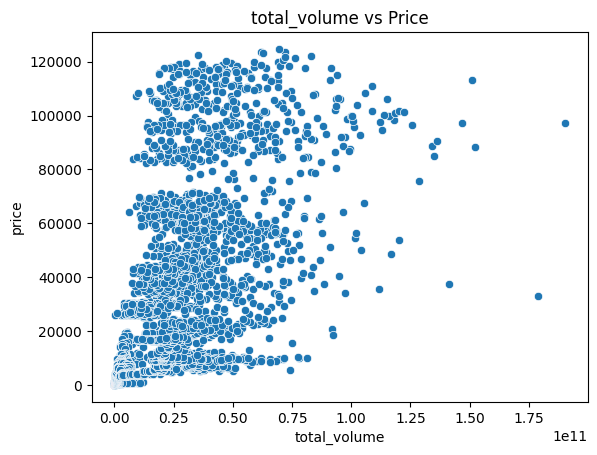

In [14]:
sns.scatterplot(x='total_volume', y='price', data=data)
plt.title("total_volume vs Price")



Text(0.5, 1.0, 'total_volume vs market_cap')

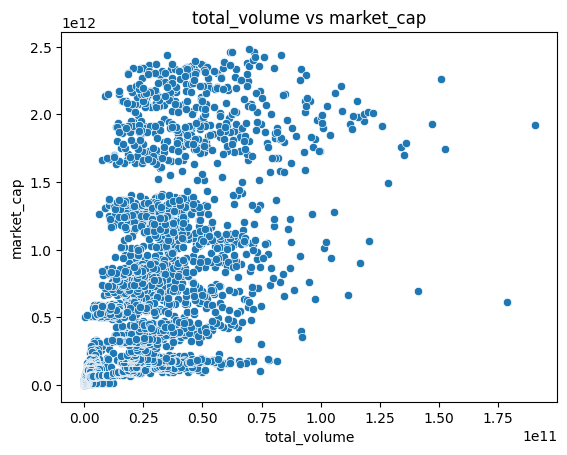

In [15]:
sns.scatterplot(x='total_volume', y='market_cap', data=data)
plt.title("total_volume vs market_cap")



# Train the Model

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


In [17]:
lr=LinearRegression()

In [18]:
X = data[['market_cap', 'total_volume']]
y = data['price']


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [20]:
X_train

,market_cap,total_volume
4182,1.189692e+12,2.948197e+10
332,7.133333e+09,2.231670e+07
1113,7.037628e+09,4.562086e+08
751,3.326080e+09,2.737318e+07
720,3.157116e+09,6.356142e+07
...,...,...
4426,2.159529e+12,3.033894e+10
466,7.749970e+09,1.227759e+07
3092,1.153847e+12,3.538545e+10
3772,5.078357e+11,4.743752e+09


In [21]:
X_test

,market_cap,total_volume
2759,3.274488e+11,3.157238e+10
1849,1.365503e+11,1.895031e+09
2277,1.752988e+11,3.386103e+10
23,1.374154e+09,0.000000e+00
1175,1.063878e+10,9.511370e+08
...,...,...
4145,1.137362e+12,2.682998e+10
4121,1.201819e+12,1.341892e+10
1149,9.286122e+09,2.116430e+09
1406,2.075306e+10,6.523226e+07


In [22]:
lr.fit(X_train, y_train)


LinearRegression()

In [23]:
y_pred = lr.predict(X_test)


In [24]:
y_pred

array([ 17443.65187267,   7359.97065112,   9880.62082629,    568.91317036,
         1049.35595042,   5982.52009352,    999.10222486,  17382.64763814,
        19295.2122363 ,    814.41014539,  20022.76673615,  84463.98412881,
       104919.66730878,  54514.84939959,   7773.77180784,   3989.22154398,
        37637.37135966,    697.52598578,   1041.35325737,   1026.7600298 ,
        10076.08526841,  93317.66885636,    803.08738245,  63241.00177367,
         6060.76731369,   6192.04750699,    907.10384879,    572.02371092,
        37894.93433694,  85777.41742766,   9570.65721523,   1934.37451321,
        63621.8662264 ,   7979.5588087 ,  27080.88193903,  87406.16015382,
          864.08336091,    747.94651576,    846.65724008,   9447.10343488,
          883.5683461 ,  56402.42521617,  38811.30117596,  85205.9711869 ,
         1457.63801804,  69924.85501114,   1167.69499444,    678.9628171 ,
        27404.86104321,    753.31308009, 103551.61081168,   5219.26458454,
          804.17679717,  

In [25]:
lr.predict([[1.731460e+12,3.991252e+10]])


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([87771.96264252])

In [26]:
lr.score(X_train, y_train)


0.9994611205111942

In [27]:
lr.score(X_test, y_test)

0.9995374448880059